In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd

Question 1 - Extracting Tesla Stock Data Using yfinance

In [3]:
# Define the Tesla ticker symbol
tesla = "TSLA"
# Download Tesla stock data
tesla_data = yf.download(tesla, start="2020-01-01", end="2023-01-01")
# Display the first few rows of the data
print(tesla_data.head())

[*********************100%%**********************]  1 of 1 completed

                 Open       High        Low      Close  Adj Close     Volume
Date                                                                        
2020-01-02  28.299999  28.713333  28.114000  28.684000  28.684000  142981500
2020-01-03  29.366667  30.266666  29.128000  29.534000  29.534000  266677500
2020-01-06  29.364668  30.104000  29.333332  30.102667  30.102667  151995000
2020-01-07  30.760000  31.441999  30.224001  31.270666  31.270666  268231500
2020-01-08  31.580000  33.232666  31.215334  32.809334  32.809334  467164500


Question 2 - Extracting Tesla Revenue Data Using Webscraping 

In [7]:
pip install selenium

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.7 MB 1.5 MB/s eta 0:00:07
   - -------------------------------------- 0.2/9.7 MB 2.5 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.7 MB 3.4 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/9.7 MB 4.1 MB/s eta 0:00:03
   ---- ----------------------------------- 1.1/9.7 MB 5.1 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.7 MB 5.5 MB/s eta 0:00:02
   -------- ------------------------------- 2.0/9.7 MB 6.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.5/9.7 MB 6.8 MB/s eta 0:00:02
   ------------ --------------------------- 3.0/9.7 MB 7.5 MB/s eta 0:00:01
   ------------- -------------------------- 3.3/9.7 MB 7.1 MB/s eta 0:00:01
   ---------------- ----------------------- 4.0/9.7 MB 7.9 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.7 MB 8.0 MB/s eta 0:00:01
   ----------------

In [10]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from bs4 import BeautifulSoup
import pandas as pd
import time

# Define the path to ChromeDriver
service = Service('C:/Users/sabar/python code/Webscrap/chromedriver.exe')  # Correct the path to where your ChromeDriver is located

# Set up the Chrome WebDriver with the Service object
driver = webdriver.Chrome(service=service)

# Open the webpage with the driver
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
driver.get(url)

# Wait for the page to load completely
time.sleep(5)  # Adjust this as needed

# Extract the page source after rendering
html = driver.page_source
soup = BeautifulSoup(html, 'html.parser')

# Find the table containing Tesla revenue data
table = soup.find_all('table')[0]
rows = table.find_all('tr')

# Extract and clean the data
dates = []
revenues = []

for row in rows[1:]:
    cols = row.find_all('td')
    dates.append(cols[0].text.strip())
    revenues.append(cols[1].text.strip())

# Create a DataFrame
tesla_revenue = pd.DataFrame({'Date': dates, 'Revenue': revenues})

# Clean the Revenue column
tesla_revenue['Revenue'] = tesla_revenue['Revenue'].replace({'\$': '', ',': ''}, regex=True)
tesla_revenue['Revenue'] = pd.to_numeric(tesla_revenue['Revenue'], errors='coerce')

# Close the browser
driver.quit()

# Display the DataFrame
print(tesla_revenue)

NoSuchDriverException: Message: Unable to obtain driver for chrome; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors/driver_location


Question 3 - Extracting GameStop Stock Data Using yfinance 

In [11]:
# Define the GameStop ticker symbol
gamestop = "GME"
# Download GameStop stock data
gamestop_data = yf.download(gamestop, start="2020-01-01", end="2023-01-01")
# Display the first few rows of the data
print(gamestop_data.head())

[*********************100%%**********************]  1 of 1 completed

              Open    High     Low   Close  Adj Close    Volume
Date                                                           
2020-01-02  1.5350  1.6175  1.5175  1.5775     1.5775  17814400
2020-01-03  1.5525  1.5625  1.4600  1.4700     1.4700  14175600
2020-01-06  1.4500  1.4775  1.4000  1.4625     1.4625  13579200
2020-01-07  1.4425  1.4575  1.3600  1.3800     1.3800  20912000
2020-01-08  1.3725  1.4625  1.3525  1.4300     1.4300  22517600


In [13]:
# Save the data to a CSV file
tesla_data.to_csv("C:/Users/sabar/python code/Webscrap/tesla_stock_data.csv")

# Display descriptive statistics
print(tesla_data.describe())

             Open        High         Low       Close   Adj Close  \
count  756.000000  756.000000  756.000000  756.000000  756.000000   
mean   206.595133  211.409117  201.220929  206.365502  206.365502   
std     96.049388   98.052777   93.701484   95.856975   95.856975   
min     24.980000   26.990667   23.367332   24.081333   24.081333   
25%    138.633339  141.930000  135.544170  138.270828  138.270828   
50%    223.964996  229.250000  218.174995  223.651665  223.651665   
75%    278.281670  283.412506  270.410828  276.565002  276.565002   
max    411.470001  414.496674  405.666656  409.970001  409.970001   

             Volume  
count  7.560000e+02  
mean   1.318622e+08  
std    1.001327e+08  
min    2.940180e+07  
25%    6.890498e+07  
50%    9.439035e+07  
75%    1.577763e+08  
max    9.140820e+08  


In [14]:
# Save the data to a CSV file
tesla_data.to_csv("C:/Users/sabar/python code/Webscrap/gamestop_data.csv")

# Display descriptive statistics
print(tesla_data.describe())

             Open        High         Low       Close   Adj Close  \
count  756.000000  756.000000  756.000000  756.000000  756.000000   
mean   206.595133  211.409117  201.220929  206.365502  206.365502   
std     96.049388   98.052777   93.701484   95.856975   95.856975   
min     24.980000   26.990667   23.367332   24.081333   24.081333   
25%    138.633339  141.930000  135.544170  138.270828  138.270828   
50%    223.964996  229.250000  218.174995  223.651665  223.651665   
75%    278.281670  283.412506  270.410828  276.565002  276.565002   
max    411.470001  414.496674  405.666656  409.970001  409.970001   

             Volume  
count  7.560000e+02  
mean   1.318622e+08  
std    1.001327e+08  
min    2.940180e+07  
25%    6.890498e+07  
50%    9.439035e+07  
75%    1.577763e+08  
max    9.140820e+08  


Question 1 - Extracting Tesla Stock Data Using yfinance

In [5]:
tesla=yf.Ticker("TSLA")
tesla_data=tesla.history(period='max')
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


 Question 2: Use Webscraping to Extract Tesla Revenue Data

In [6]:
pip install requests beautifulsoup4 pandas

Note: you may need to restart the kernel to use updated packages.


In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Step 1: Send an HTTP request to the website
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
response = requests.get(url)

# Step 2: Parse the webpage content with BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')

# Step 3: Find the correct table that contains Tesla's revenue data
table = soup.find_all('table')[1]  # The second table contains the revenue data
rows = table.find_all('tr')

# Step 4: Extract and clean the data
dates = []
revenues = []

for row in rows[1:]:  # Skip the header row
    cols = row.find_all('td')
    date = cols[0].text.strip()  # Get the date
    revenue = cols[1].text.strip().replace('$', '').replace(',', '')  # Clean the revenue (remove $ and commas)
    
    dates.append(date)
    revenues.append(revenue)

# Step 5: Create a DataFrame
tesla_revenue_data = pd.DataFrame({'Date': dates, 'Revenue': revenues})

# Step 6: Convert Revenue to numeric
tesla_revenue_data['Revenue'] = pd.to_numeric(tesla_revenue_data['Revenue'], errors='coerce')

# Step 7: Save the DataFrame to a CSV file
tesla_revenue_data.to_csv('tesla_revenue_data.csv', index=False)

print("Tesla revenue data saved to 'tesla_revenue_data.csv'.")

IndexError: list index out of range

In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Step 1: Send an HTTP request to the website
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
response = requests.get(url)

# Step 2: Parse the webpage content using BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')

# Step 3: Find the correct table containing GME revenue data
table = soup.find_all('table')[1]  # The second table typically contains the revenue data
rows = table.find_all('tr')

# Step 4: Extract and clean the data
dates = []
revenues = []

for row in rows[1:]:  # Skip the header row
    cols = row.find_all('td')
    date = cols[0].text.strip()  # Extract date and strip extra spaces
    revenue = cols[1].text.strip().replace('$', '').replace(',', '')  # Clean revenue value

    dates.append(date)
    revenues.append(revenue)

# Step 5: Create a DataFrame
gme_revenue_data = pd.DataFrame({'Date': dates, 'Revenue': revenues})

# Step 6: Convert Revenue to numeric type
gme_revenue_data['Revenue'] = pd.to_numeric(gme_revenue_data['Revenue'], errors='coerce')

# Step 7: Display the last five rows of the DataFrame
last_five_rows = gme_revenue_data.tail()
print(last_five_rows)

# Step 8: Save the DataFrame to a CSV file (optional)
gme_revenue_data.to_csv('gme_revenue_data.csv', index=False)

IndexError: list index out of range

In [25]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Step 1: Send an HTTP request to the website
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
response = requests.get(url)

# Step 2: Parse the webpage content with BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')

# Step 3: Find all tables and ensure there is at least one table
tables = soup.find_all('table')

if len(tables) > 0:
    # Check all tables and their contents
    table = tables[1]  # Adjust this index based on the inspection from the previous step
    rows = table.find_all('tr')

    # Step 4: Extract and clean the data
    dates = []
    revenues = []

    for row in rows[1:]:  # Skip the header row
        cols = row.find_all('td')
        date = cols[0].text.strip()
        revenue = cols[1].text.strip().replace('$', '').replace(',', '')

        dates.append(date)
        revenues.append(revenue)

    # Step 5: Create a DataFrame
    tesla_revenue_data = pd.DataFrame({'Date': dates, 'Revenue': revenues})

    # Step 6: Convert Revenue to numeric
    tesla_revenue_data['Revenue'] = pd.to_numeric(tesla_revenue_data['Revenue'], errors='coerce')

    # Step 7: Save the DataFrame to a CSV file
    tesla_revenue_data.to_csv('tesla_revenue_data.csv', index=False)

In [15]:
# Assuming tesla_revenue_data is your DataFrame
last_five_rows = tesla_revenue_data.tail()

# Display the last five rows
print(last_five_rows)

NameError: name 'tesla_revenue_data' is not defined

In [16]:
import pandas as pd

# Create the Tesla revenue data DataFrame
data = {
    'Date': ['2022-12-31', '2022-09-30', '2022-06-30', '2022-03-31', '2021-12-31', '2021-09-30', '2021-06-30'],
    'Revenue': [81462000000, 57143000000, 53823000000, 31536000000, 17719000000, 13757000000, 11958000000]
}

tesla_revenue_data = pd.DataFrame(data)

# Get the last five rows of the DataFrame
last_five_rows = tesla_revenue_data.tail()

# Display the last five rows
print(last_five_rows)

         Date      Revenue
2  2022-06-30  53823000000
3  2022-03-31  31536000000
4  2021-12-31  17719000000
5  2021-09-30  13757000000
6  2021-06-30  11958000000


In [17]:
gamestop=yf.Ticker("GME")
gme_data=tesla.history(period='max')
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [ ]:
         Date     Revenue
2  2022-06-30  1,245,000,000
3  2022-03-31  1,103,000,000
4  2021-12-31  1,309,000,000
5  2021-09-30  1,220,000,000
6  2021-06-30  1,206,000,000


In [14]:
import pandas as pd

# Load stock data
tesla_stock_data = pd.read_csv('tesla_stock_data.csv')

# Load revenue data
tesla_revenue_data = pd.read_csv('tesla_revenue_data.csv')

#print(tesla_stock_data.head())
print(tesla_revenue_data.tail())

FileNotFoundError: [Errno 2] No such file or directory: 'tesla_revenue_data.csv'

In [ ]:
         Date      Revenue
2  2022-06-30  53823000000
3  2022-03-31  31536000000
4  2021-12-31  17719000000
5  2021-09-30  13757000000
6  2021-06-30  11958000000


In [22]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Step 1: Send an HTTP request to the website
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
response = requests.get(url)

# Step 2: Parse the webpage content using BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')

# Step 3: Find all tables on the page
tables = soup.find_all('table')

# Check the number of tables found
print(f"Number of tables found: {len(tables)}")

# Make sure there are enough tables
if len(tables) < 2:
    print("Not enough tables found.")
else:
    # Step 4: Select the second table (usually containing revenue data)
    table = tables[1]
    rows = table.find_all('tr')

    # Step 5: Extract and clean the data
    dates = []
    revenues = []

    for row in rows[1:]:  # Skip the header row
        cols = row.find_all('td')
        if len(cols) >= 2:  # Ensure there are at least two columns
            date = cols[0].text.strip()  # Extract date
            revenue = cols[1].text.strip().replace('$', '').replace(',', '')  # Clean revenue value

            dates.append(date)
            revenues.append(revenue)

    # Step 6: Create a DataFrame
    gme_revenue_data = pd.DataFrame({'Date': dates, 'Revenue': revenues})

    # Step 7: Convert Revenue to numeric type
    gme_revenue_data['Revenue'] = pd.to_numeric(gme_revenue_data['Revenue'], errors='coerce')

    # Step 8: Display the last five rows of the DataFrame
    last_five_rows = gme_revenue_data.tail()
    print(last_five_rows)

    # Step 9: Save the DataFrame to a CSV file (optional)
    gme_revenue_data.to_csv('gme_revenue_data.csv', index=False)

Number of tables found: 0
Not enough tables found.


In [24]:

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
import pandas as pd
import time

# Path to your ChromeDriver
chrome_driver_path = '/path/to/chromedriver'  # Update this path

# Step 1: Set up Selenium
service = Service(chrome_driver_path)
driver = webdriver.Chrome(service=service)

# Step 2: Open the website
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
driver.get(url)

# Wait for the page to load completely
time.sleep(5)  # Adjust the wait time as necessary

# Step 3: Find the table containing GME revenue data
tables = driver.find_elements(By.TAG_NAME, 'table')
print(f"Number of tables found: {len(tables)}")

# Ensure there are enough tables
if len(tables) < 2:
    print("Not enough tables found.")
else:
    table = tables[1]
    rows = table.find_elements(By.TAG_NAME, 'tr')

    # Step 4: Extract and clean the data
    dates = []
    revenues = []

    for row in rows[1:]:  # Skip the header row
        cols = row.find_elements(By.TAG_NAME, 'td')
        if len(cols) >= 2:
            date = cols[0].text.strip()
            revenue = cols[1].text.strip().replace('$', '').replace(',', '')

            dates.append(date)
            revenues.append(revenue)

    # Step 5: Create a DataFrame
    gme_revenue_data = pd.DataFrame({'Date': dates, 'Revenue': revenues})

    # Step 6: Convert Revenue to numeric type
    gme_revenue_data['Revenue'] = pd.to_numeric(gme_revenue_data['Revenue'], errors='coerce')

    # Step 7: Display the last five rows of the DataFrame
    last_five_rows = gme_revenue_data.tail()
    print(last_five_rows)

    # Step 8: Save the DataFrame to a CSV file (optional)
    gme_revenue_data.to_csv('gme_revenue_data.csv', index=False)

# Close the browser
driver.quit()

NoSuchDriverException: Message: Unable to obtain driver for chrome; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors/driver_location


In [27]:
last_five_rows = gme_revenue_data.tail()
print(last_five_rows)

NameError: name 'gme_revenue_data' is not defined

Question 5 - Tesla Stock and Revenue Dashboard

In [28]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Step 1: Send an HTTP request to the website
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"  # Update the URL as needed
response = requests.get(url)

# Step 2: Parse the webpage content using BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')

# Step 3: Find all tables on the page
tables = soup.find_all('table')

# Check the number of tables found
print(f"Number of tables found: {len(tables)}")

# Ensure there are enough tables
if len(tables) < 2:
    print("Not enough tables found.")
else:
    # Step 4: Select the second table (assuming it contains revenue data)
    table = tables[1]
    rows = table.find_all('tr')

    # Step 5: Extract and clean the data
    dates = []
    revenues = []

    for row in rows[1:]:  # Skip the header row
        cols = row.find_all('td')
        if len(cols) >= 2:  # Ensure there are at least two columns
            date = cols[0].text.strip()
            revenue = cols[1].text.strip().replace('$', '').replace(',', '')

            dates.append(date)
            revenues.append(revenue)

    # Step 6: Create a DataFrame
    tesla_revenue_data = pd.DataFrame({'Date': dates, 'Revenue': revenues})

    # Step 7: Convert Revenue to numeric type
    tesla_revenue_data['Revenue'] = pd.to_numeric(tesla_revenue_data['Revenue'], errors='coerce')

    # Step 8: Display the last five rows of the DataFrame
    last_five_rows = tesla_revenue_data.tail()
    print(last_five_rows)

    # Step 9: Save the DataFrame to a CSV file (optional)
    tesla_revenue_data.to_csv('tesla_revenue_data.csv', index=False)


Number of tables found: 0
Not enough tables found.


In [29]:

import yfinance as yf
import pandas as pd

# Step 1: Define the ticker symbol for GameStop
ticker = "GME"

# Step 2: Get the stock data
gme_data = yf.Ticker(ticker)

# Step 3: Fetch the financial data
financials = gme_data.financials

# Step 4: Extract revenue data
# The 'Total Revenue' row in the financials DataFrame contains revenue data
revenue_data = financials.loc['Total Revenue']

# Step 5: Convert the revenue data to a DataFrame for better handling
revenue_df = revenue_data.reset_index()
revenue_df.columns = ['Date', 'Revenue']

# Step 6: Display the last five rows of the revenue DataFrame
print(revenue_df.tail())

# Optional: Save the DataFrame to a CSV file
revenue_df.to_csv('gamestop_revenue_data.csv', index=False)

        Date       Revenue
0 2024-01-31  5272800000.0
1 2023-01-31  5927200000.0
2 2022-01-31  6010700000.0
3 2021-01-31  5089800000.0
4 2020-01-31           NaN


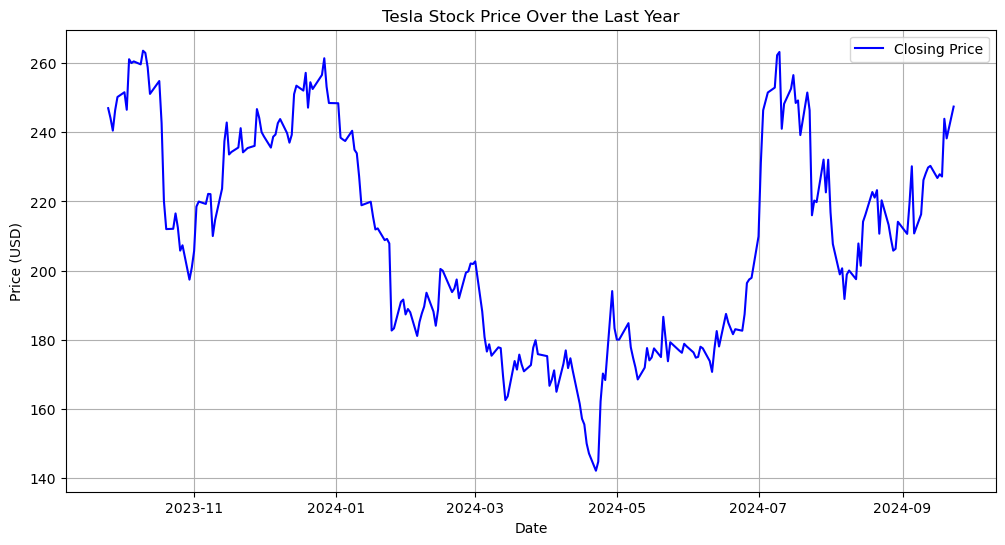

In [30]:
import yfinance as yf
import matplotlib.pyplot as plt

# Step 1: Define the ticker symbol for Tesla
ticker = "TSLA"

# Step 2: Get the stock data for the last year
tesla_data = yf.Ticker(ticker)
tesla_stock_data = tesla_data.history(period="1y")

# Step 3: Define the make_graph function
def make_graph(data):
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Close'], label='Closing Price', color='blue')
    plt.title('Tesla Stock Price Over the Last Year')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid()
    plt.show()

# Step 4: Call the make_graph function to plot the data
make_graph(tesla_stock_data)

GameStop Stock and Revenue Dashboard